In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import json
from typing import Union


def read_json(in_file: Union[Path, str]):
    if not isinstance(in_file, Path):
        in_file = Path(in_file)
    return json.loads(in_file.read_text(encoding='utf8'))

In [4]:
METRIC_LIST = ['depth_ratio', 'ops_ratio', 'cx_ratio']

def wide_to_long(df):
    df = pd.melt(
        df,
        id_vars=[col for col in df.columns if col not in METRIC_LIST],
        value_vars=METRIC_LIST,
        var_name='metric',
        value_name='value'
    )
    return df

In [5]:
def get_ours_metrics(dir:  Path):
    if not isinstance(dir, Path):
        dir = Path(dir)
    assert dir.is_dir(), dir

    records = []
    for subdir in dir.iterdir():
        try:
            metrics = read_json(subdir / 'metrics.json')
            config = read_json(subdir / 'config.json')
        except:
            continue
        rec = {key.replace('metric/', ''): value for key, value in metrics.items()}
        rec.update(graph_name=config['hardware'].lower(),
                   circuit=config['circuit'],
                   layout_method=config['init_strategy'].lower() + '-ours',
                   opt_method='ours',
                   routing_method='ours',
                   opt_order='ours')
        records.append(rec)

    return pd.DataFrame.from_records(records)

df_ours = wide_to_long(get_ours_metrics('./output/ours/nam_circs'))

<Axes: xlabel='circuit', ylabel='value'>

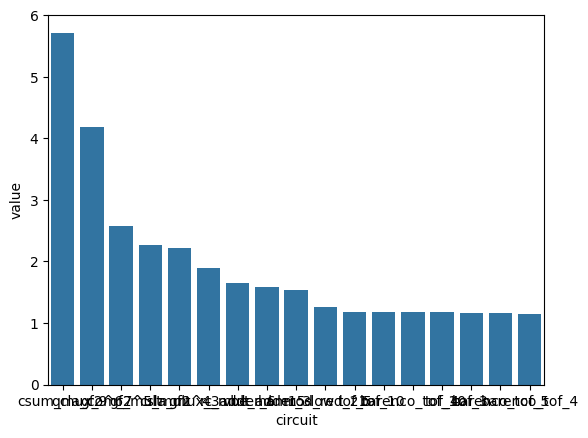

In [6]:
sns.barplot(df_ours[df_ours.metric == 'depth_ratio'].sort_values('value', ascending=False), x='circuit', y='value')

In [8]:
df_baseline = wide_to_long(
    pd.concat([
        pd.read_csv('./output/baseline/nam_circs.csv'),
        pd.read_csv('./output/baseline/nam_circs_qtz.csv'),
        ]))
df_baseline = df_baseline[df_baseline.graph_name == 'star']

In [9]:
len(df_ours.circuit.unique()), len(df_baseline.circuit.unique())

(17, 21)

In [10]:
df = pd.concat([df_ours, df_baseline], axis=0)


In [11]:
def plot_bar_comparison(df, title, x, hue=None):
    plt.figure(figsize=(15,3))
    plt.suptitle(title)

    for i, metric in enumerate(METRIC_LIST):
        ax = plt.subplot(1,len(METRIC_LIST),i+1)
        sns.barplot(df[df.metric == metric], y='value', x=x, ax=ax, legend=bool(hue), hue=hue)
        ax.set_ylabel('')
        ax.set_xlabel(metric)
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

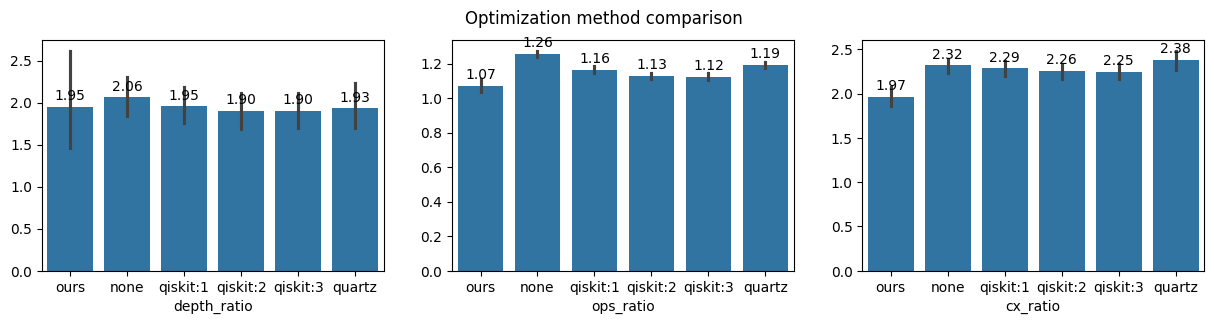

In [12]:
plot_bar_comparison(df, title='Optimization method comparison', x='opt_method')

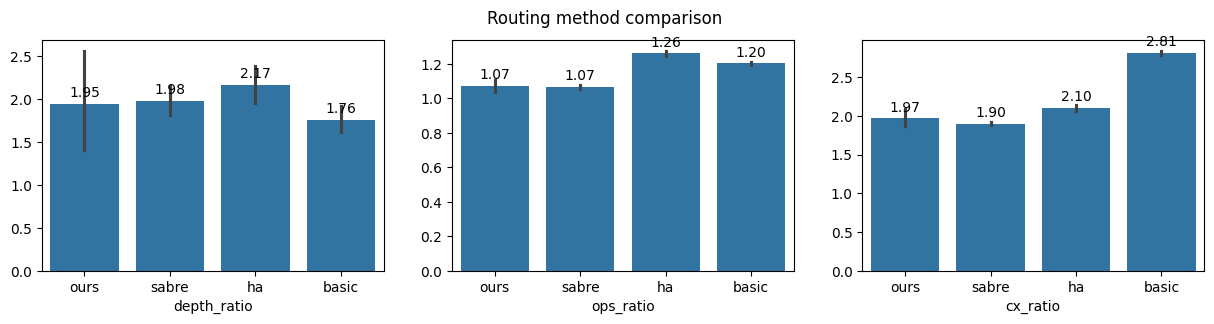

In [13]:
plot_bar_comparison(df, title='Routing method comparison', x='routing_method')


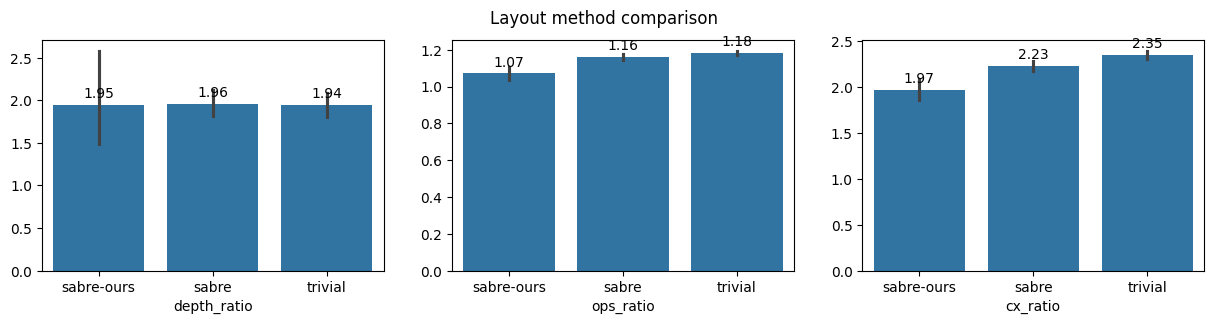

In [14]:
plot_bar_comparison(df, title='Layout method comparison', x='layout_method')